In [26]:
!pip install tensorflow tensorflow_hub librosa numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Section 1 — Imports & Setup

In [28]:
import os
import glob
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (8, 6)


## Section 2 — Dataset Loading (mini_speech_commands)


In [38]:
import zipfile

DATA_URL = "http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip"

zip_path = tf.keras.utils.get_file(
    "mini_speech_commands.zip",
    origin=DATA_URL,
    extract=False,
    cache_dir=".",
    cache_subdir="data",
)

extract_dir = os.path.join(".", "data", "mini_speech_commands_extracted")
if not os.path.isdir(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

data_dir = os.path.join(extract_dir, "mini_speech_commands")

commands = sorted([d for d in os.listdir(data_dir)
                    if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith("_")])
print("Available word classes:", commands)

Available word classes: ['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes']


In [40]:

SELECTED_CLASSES = commands[:4] 
CLIPS_PER_CLASS = 2

selected_files = []
selected_labels = []
for cls in SELECTED_CLASSES:
    files = sorted(glob.glob(os.path.join(data_dir, cls, "*.wav")))[:CLIPS_PER_CLASS]
    selected_files.extend(files)
    selected_labels.extend([cls] * len(files))

print(f"Selected {len(selected_files)} clips across classes: {SELECTED_CLASSES}")
for f, l in zip(selected_files, selected_labels):
    print(f" - [{l}] {os.path.basename(f)}")


Selected 8 clips across classes: ['down', 'go', 'left', 'no']
 - [down] 004ae714_nohash_0.wav
 - [down] 00b01445_nohash_1.wav
 - [go] 004ae714_nohash_0.wav
 - [go] 0132a06d_nohash_2.wav
 - [left] 00b01445_nohash_0.wav
 - [left] 012c8314_nohash_0.wav
 - [no] 012c8314_nohash_0.wav
 - [no] 0132a06d_nohash_1.wav


## Section 3 — Preprocessing

YAMNet expects mono audio at 16 kHz as a 1-D float32 waveform in [-1, 1].


In [43]:
TARGET_SR = 16000

def load_clip(path, sr=TARGET_SR):
    y, _ = librosa.load(path, sr=sr, mono=True)
    peak = np.max(np.abs(y))
    if peak > 0:
        y = y / peak
    return y.astype(np.float32)

waveforms = [load_clip(f) for f in selected_files]

for f, l, wav in zip(selected_files, selected_labels, waveforms):
    print(f"[{l}] {os.path.basename(f)} — {len(wav)/TARGET_SR:.2f}s")

display(Audio(waveforms[0], rate=TARGET_SR))


[down] 004ae714_nohash_0.wav — 1.00s
[down] 00b01445_nohash_1.wav — 1.00s
[go] 004ae714_nohash_0.wav — 0.70s
[go] 0132a06d_nohash_2.wav — 1.00s
[left] 00b01445_nohash_0.wav — 1.00s
[left] 012c8314_nohash_0.wav — 1.00s
[no] 012c8314_nohash_0.wav — 1.00s
[no] 0132a06d_nohash_1.wav — 1.00s


## Section 4 — Embedding Extraction with YAMNet

YAMNet outputs frame-level embeddings (one 1024-d vector per ~0.96s audio frame); we mean-pool across
frames to get a single fixed-length embedding per clip.


In [45]:
print("Loading YAMNet from TensorFlow Hub (~15 MB, cached after first download)...")
yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")
print("YAMNet loaded.")


Loading YAMNet from TensorFlow Hub (~15 MB, cached after first download)...



YAMNet loaded.


In [46]:
def get_embedding(waveform, model):
    _, embeddings, _ = model(waveform)
    return tf.reduce_mean(embeddings, axis=0).numpy()

embeddings = np.stack([get_embedding(wav, yamnet_model) for wav in waveforms])
labels = [f"{l}_{i}" for i, l in enumerate(selected_labels)]

print("Embeddings shape:", embeddings.shape) 


Embeddings shape: (8, 1024)


## Section 5 — Pairwise Similarity & Distance

In [48]:
sim_matrix = cosine_similarity(embeddings)
dist_matrix = euclidean_distances(embeddings)

print("Cosine similarity matrix:")
print(np.round(sim_matrix, 3))
print()
print("Euclidean distance matrix:")
print(np.round(dist_matrix, 3))


Cosine similarity matrix:
[[1.    0.615 0.44  0.666 0.786 0.455 0.476 0.67 ]
 [0.615 1.    0.511 0.498 0.705 0.574 0.644 0.592]
 [0.44  0.511 1.    0.394 0.531 0.451 0.463 0.453]
 [0.666 0.498 0.394 1.    0.672 0.26  0.306 0.809]
 [0.786 0.705 0.531 0.672 1.    0.562 0.614 0.739]
 [0.455 0.574 0.451 0.26  0.562 1.    0.78  0.367]
 [0.476 0.644 0.463 0.306 0.614 0.78  1.    0.41 ]
 [0.67  0.592 0.453 0.809 0.739 0.367 0.41  1.   ]]

Euclidean distance matrix:
[[0.    5.14  6.082 7.058 3.935 5.905 5.745 5.597]
 [5.14  0.    4.937 8.215 3.943 4.481 4.04  5.907]
 [6.082 4.937 0.    8.775 4.893 4.976 4.831 6.675]
 [7.058 8.215 8.775 0.    7.107 9.382 9.128 5.576]
 [3.935 3.943 4.893 7.107 0.    4.603 4.267 4.896]
 [5.905 4.481 4.976 9.382 4.603 0.    2.976 7.024]
 [5.745 4.04  4.831 9.128 4.267 2.976 0.    6.774]
 [5.597 5.907 6.675 5.576 4.896 7.024 6.774 0.   ]]


## Section 6 — Visualization

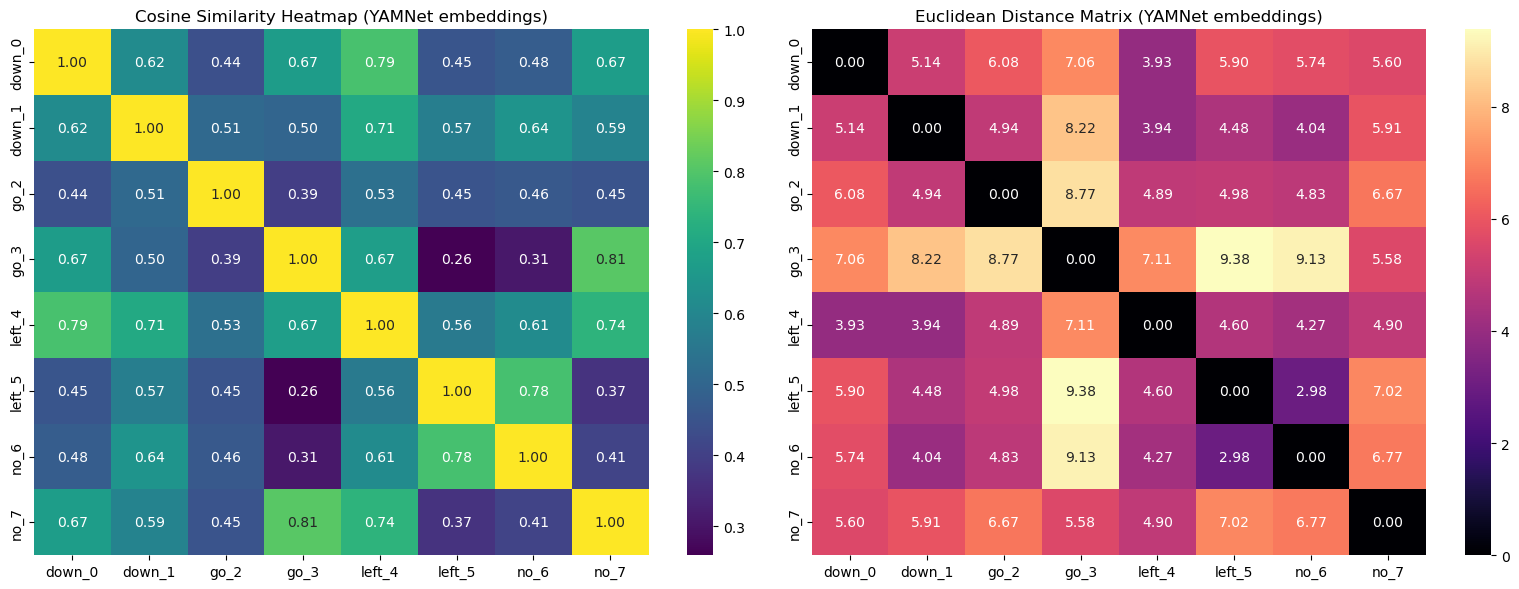

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Cosine Similarity Heatmap (YAMNet embeddings)")

sns.heatmap(dist_matrix, annot=True, fmt=".2f", cmap="magma",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Euclidean Distance Matrix (YAMNet embeddings)")

plt.tight_layout()
plt.show()


## Observations

Within-class pairs

down_0 vs down_1: 0.62 cosine / 5.14 distance — moderate similarity, not very tight.
left_4 vs left_5: 0.56 / 4.60 — moderate.
no_6 vs no_7: 0.41 / 6.77 — surprisingly low similarity for a same-class pair.
go_2 vs go_3: 0.39 / 8.77 — the lowest within-class similarity in the whole matrix, and highest distance too.
So within-class clustering is weak-to-moderate overall, not strongly separated — matches the notebook's expectation that YAMNet embeddings are general-purpose (AudioSet event tagging), not fine-tuned for word discrimination.

Cross-class pairs

Some cross-class pairs are more similar than within-class ones: go_3 & no_7 = 0.81 (highest off-diagonal value in the matrix!), left_4 & down_0 = 0.79, left_5 & no_6 = 0.78.
This means YAMNet is grouping some different-word clips closer together than same-word clips — likely due to shared acoustic traits (similar pitch, speaker voice, or short transient burst pattern) rather than semantic word content.

Euclidean distance

Distance matrix broadly agrees with cosine similarity (inversely) — e.g. left_5/no_6 has the lowest distance (2.98) and highest similarity (0.78) pair.
go_3 has the largest distances to almost everything except no_7, suggesting it's an acoustic outlier clip.
